# Практика 2

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

from skimage.metrics import structural_similarity, mean_squared_error

def add_gaussian_noise(image, mean=0, stddev=25):
    """Apply gaaussian noise to image"""
    noise = np.zeros(image.shape, np.uint8)
    cv2.randn(noise, mean, stddev)
    noisy_image = cv2.add(image, noise)
    return noisy_image

def add_salt_pepper_noise(image, amount=0.05):
    """Apply Salt and Pepper noise"""
    noisy_image = copy.deepcopy(image)
    h, w = image.shape[:2]
    num = int(amount * h * w)

    # Salt
    ys = np.random.randint(0, h, num)
    xs = np.random.randint(0, w, num)
    noisy_image[ys, xs] = 255

    # Pepper
    ys = np.random.randint(0, h, num)
    xs = np.random.randint(0, w, num)
    noisy_image[ys, xs] = 0

    return noisy_image

def add_uniform_noise(image, low=0, high=50):
    """Apply uniform noise"""
    noise = np.zeros(image.shape, np.uint8)
    cv2.randu(noise, low, high)
    noisy_image = cv2.add(image, noise)
    return noisy_image

def compare_filters(original, noisy, filters_dict):
    print(f"{'Filter':<25} | {'MSE':<10} | {'SSIM':<8}")
    print('-' * 50)

    mse = mean_squared_error(original, noisy)
    ssim = structural_similarity(original, noisy)
    print(f"{'Noisy':<25} | {mse:<10.1f} | {ssim:<8.3f}")

    for name, img in filters_dict.items():
        mse = mean_squared_error(original, img)
        ssim = structural_similarity(original, img)
        print(f"{name:<25} | {mse:<10.1f} | {ssim:<8.3f}")

def showpic(image, text):
    plt.imshow(image, cmap='gray')
    plt.title(text)
    plt.show()

## Шум Гаусса

Filter                    | MSE        | SSIM    
--------------------------------------------------
Noisy                     | 4499.6     | 0.026   
Median                    | 332.7      | 0.366   
Gauss Filter              | 1729.5     | 0.231   
Bilateral                 | 1364.9     | 0.352   
NLM h=10                  | 4499.5     | 0.026   
NLM h=25                  | 4160.3     | 0.036   
NLM h=50                  | 1430.6     | 0.550   


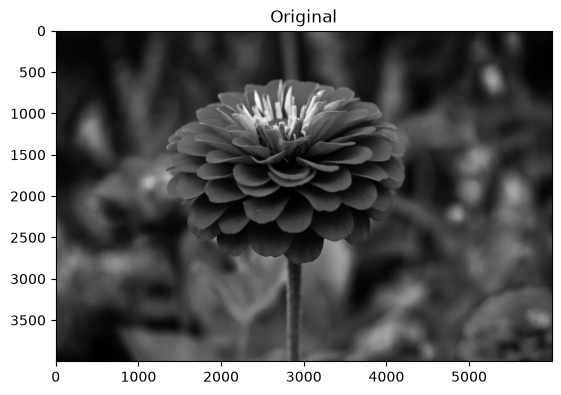

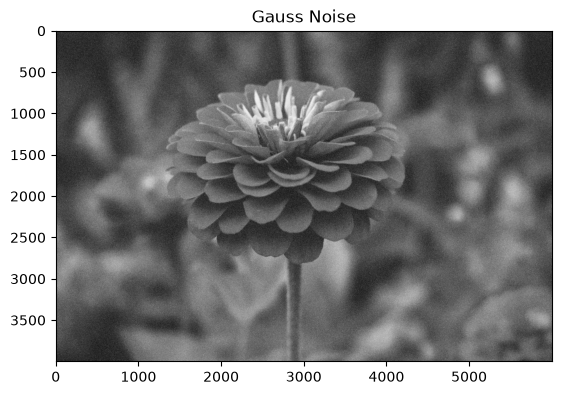

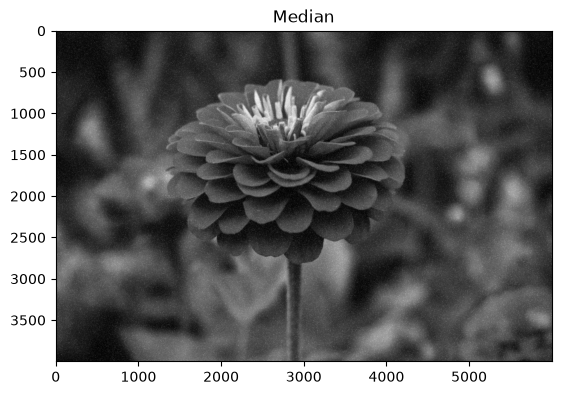

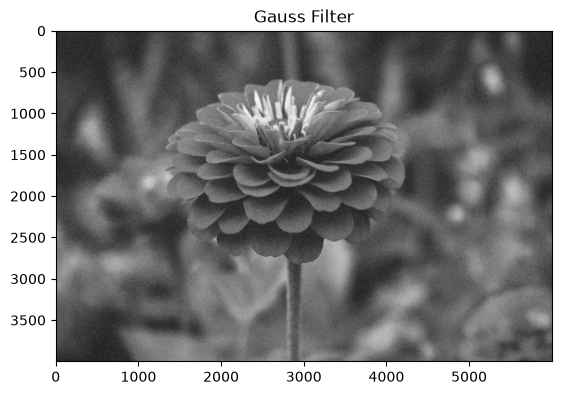

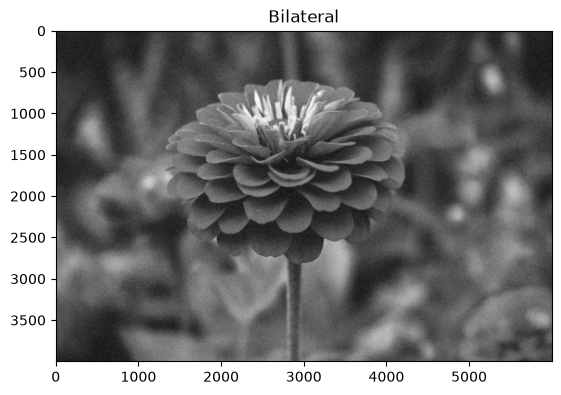

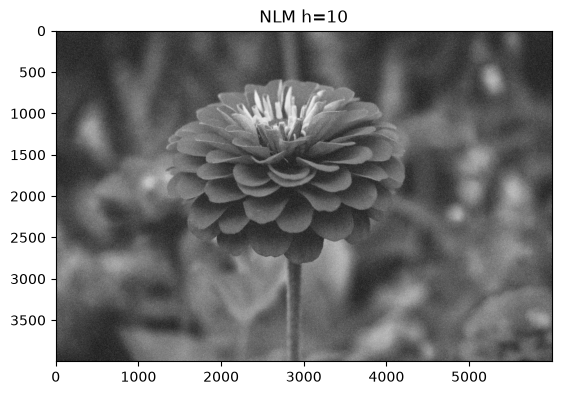

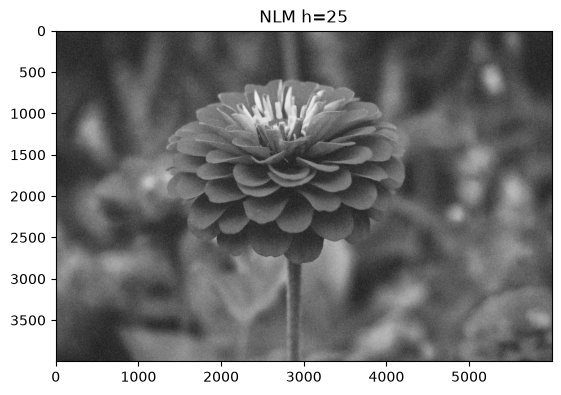

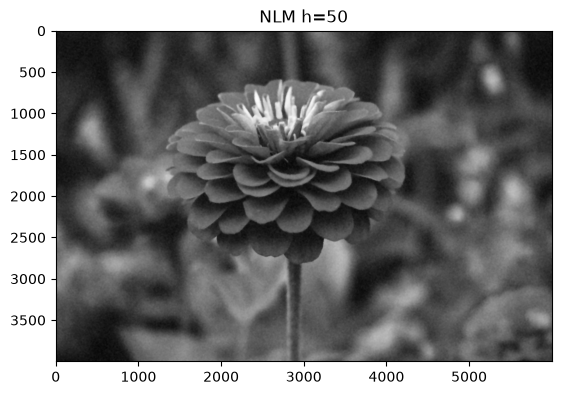

In [10]:
image = cv2.imread('source/target_img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

noisy_gauss = add_gaussian_noise(image_gray, mean=0, stddev=100)

denoised_gauss_median = cv2.medianBlur(noisy_gauss, 5)
denoised_gauss_gaussian = cv2.GaussianBlur(noisy_gauss, (5,5), 0)
denoised_gauss_bilateral = cv2.bilateralFilter(noisy_gauss, 9, 150, 9)
denoised_gauss_nlm_10 = cv2.fastNlMeansDenoising(noisy_gauss, h=10)
denoised_gauss_nlm_25 = cv2.fastNlMeansDenoising(noisy_gauss, h=25)
denoised_gauss_nlm_50 = cv2.fastNlMeansDenoising(noisy_gauss, h=50)

filters_gauss = {
    "Median": denoised_gauss_median,
    "Gauss Filter": denoised_gauss_gaussian,
    "Bilateral": denoised_gauss_bilateral,
    "NLM h=10": denoised_gauss_nlm_10,
    "NLM h=25": denoised_gauss_nlm_25,
    "NLM h=50": denoised_gauss_nlm_50,
}

compare_filters(image_gray, noisy_gauss, filters_gauss)

showpic(image_gray, 'Original')
showpic(noisy_gauss, 'Gauss Noise')
for name, pic in filters_gauss.items():
    showpic(pic, f"{name}")

## Шум "Соль и перец"

Filter                    | MSE        | SSIM    
--------------------------------------------------
Noisy                     | 2102.8     | 0.091   
Median                    | 12.2       | 0.855   
Gauss Filter              | 214.3      | 0.371   
Bilateral                 | 1111.2     | 0.196   
NLM h=10                  | 2094.5     | 0.097   
NLM h=25                  | 947.8      | 0.260   
NLM h=50                  | 51.3       | 0.757   


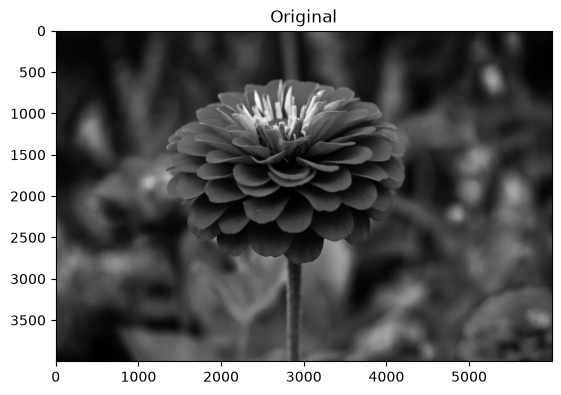

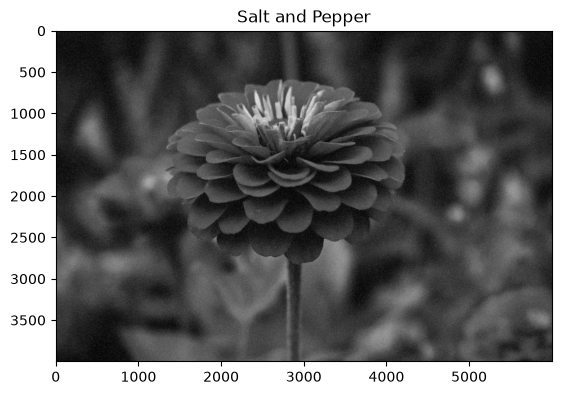

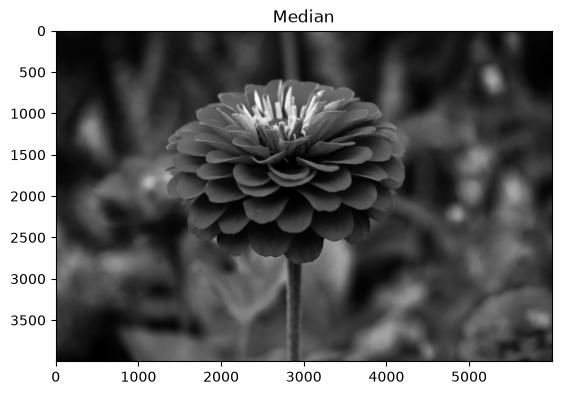

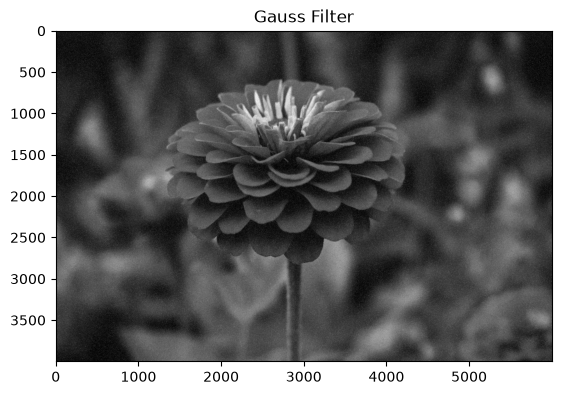

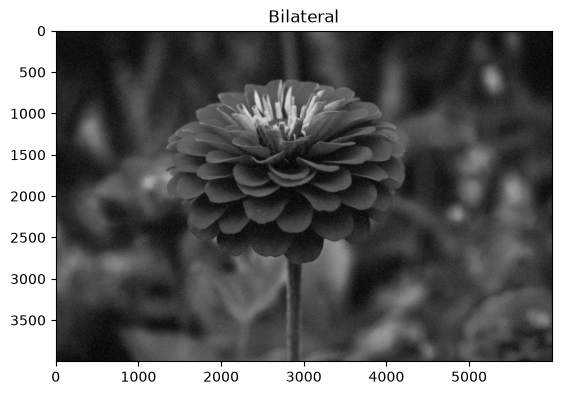

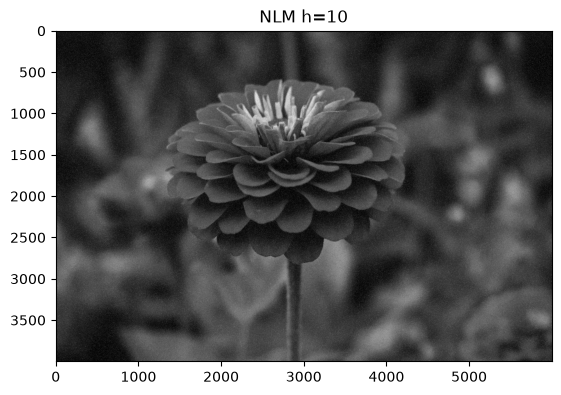

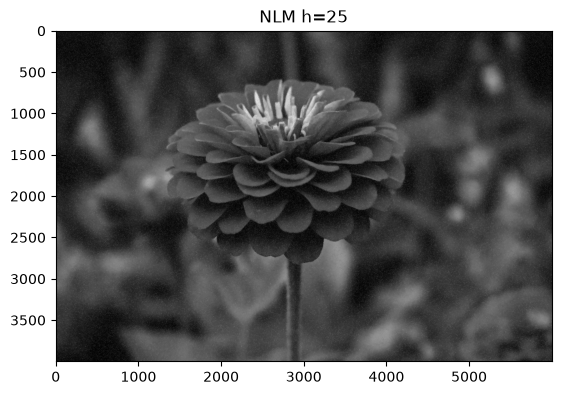

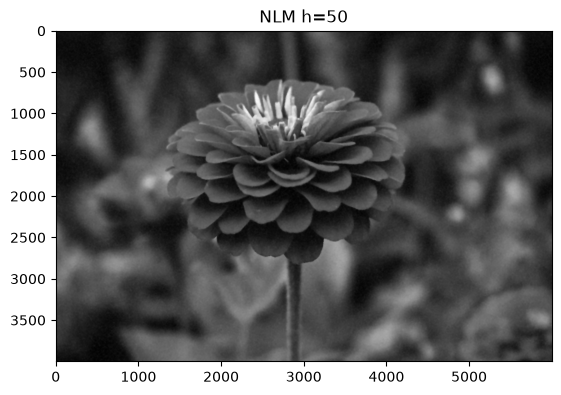

In [11]:
noisy_sp = add_salt_pepper_noise(image_gray, amount=0.05)

denoised_sp_median = cv2.medianBlur(noisy_sp, 5)
denoised_sp_gaussian = cv2.GaussianBlur(noisy_sp, (5, 5), 0)
denoised_sp_bilateral = cv2.bilateralFilter(noisy_sp, 9, 75, 75)
denoised_sp_nlm_10 = cv2.fastNlMeansDenoising(noisy_sp, h=10)
denoised_sp_nlm_25 = cv2.fastNlMeansDenoising(noisy_sp, h=25)
denoised_sp_nlm_50 = cv2.fastNlMeansDenoising(noisy_sp, h=50)

filters_sp = {
    "Median": denoised_sp_median,
    "Gauss Filter": denoised_sp_gaussian,
    "Bilateral": denoised_sp_bilateral,
    "NLM h=10": denoised_sp_nlm_10,
    "NLM h=25": denoised_sp_nlm_25,
    "NLM h=50": denoised_sp_nlm_50
}

compare_filters(image_gray, noisy_sp, filters_sp)

showpic(image_gray, 'Original')
showpic(noisy_sp, 'Salt and Pepper')
for name, pic in filters_sp.items():
    showpic(pic, f"{name}")

## Постоянный Шум

Filter                    | MSE        | SSIM    
--------------------------------------------------
Noisy                     | 3277.1     | 0.074   
Median                    | 2552.6     | 0.341   
Gauss Filter              | 2516.1     | 0.406   
Bilateral                 | 2490.7     | 0.483   
NLM h=10                  | 3276.8     | 0.075   
NLM h=25                  | 2465.7     | 0.586   
NLM h=50                  | 2462.2     | 0.615   


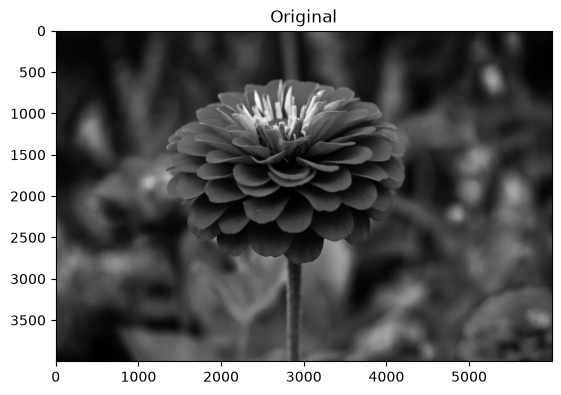

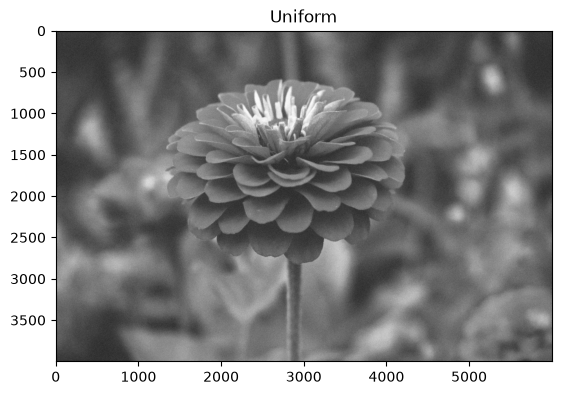

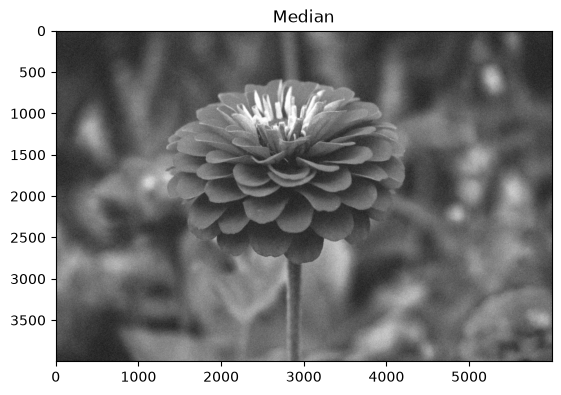

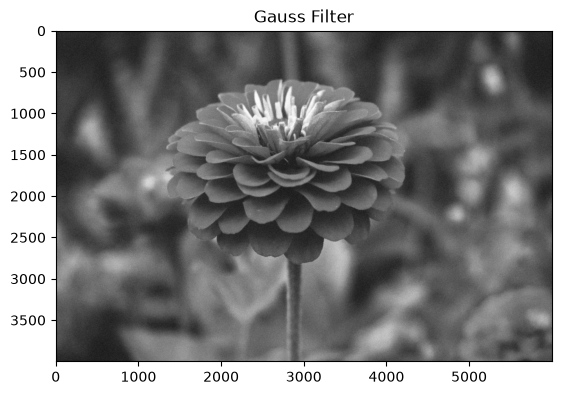

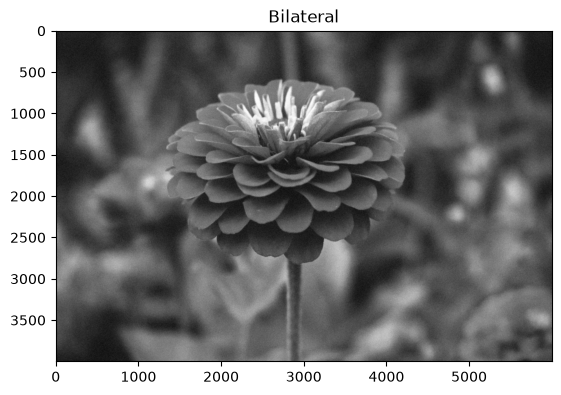

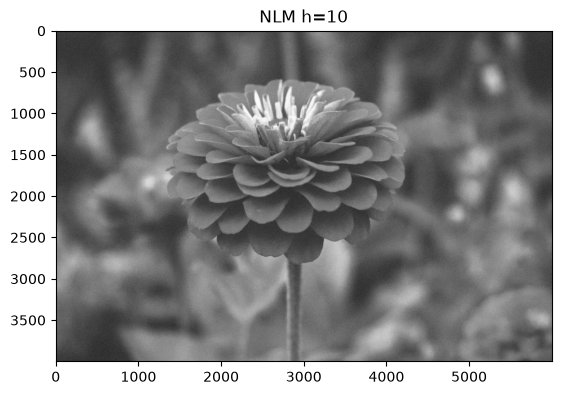

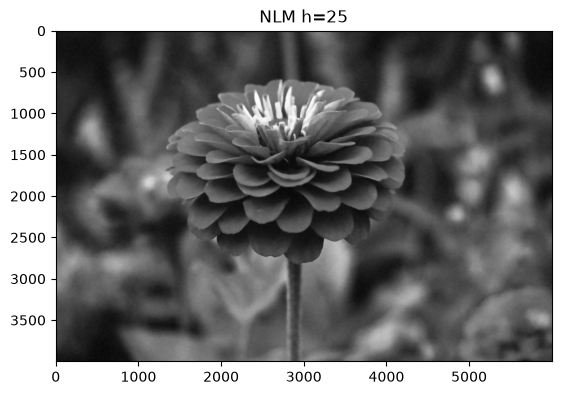

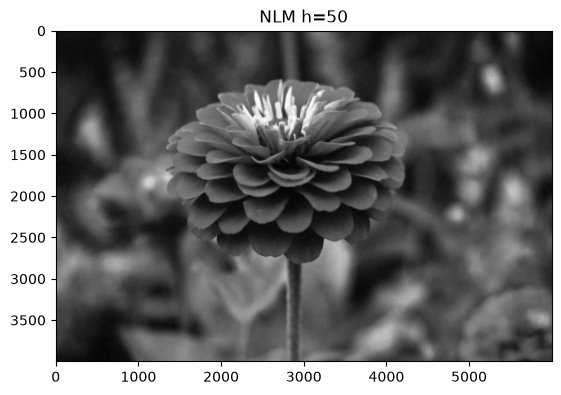

In [12]:
noisy_uniform = add_uniform_noise(image_gray, low=0, high=100)

denoised_uni_median = cv2.medianBlur(noisy_uniform, 5)
denoised_uni_gaussian = cv2.GaussianBlur(noisy_uniform, (5, 5), 0)
denoised_uni_bilateral = cv2.bilateralFilter(noisy_uniform, 9, 75, 75)
denoised_uni_nlm_10 = cv2.fastNlMeansDenoising(noisy_uniform, h=10)
denoised_uni_nlm_25 = cv2.fastNlMeansDenoising(noisy_uniform, h=25)
denoised_uni_nlm_50 = cv2.fastNlMeansDenoising(noisy_uniform, h=50)

filters_uni = {
    "Median": denoised_uni_median,
    "Gauss Filter": denoised_uni_gaussian,
    "Bilateral": denoised_uni_bilateral,
    "NLM h=10": denoised_uni_nlm_10,
    "NLM h=25": denoised_uni_nlm_25,
    "NLM h=50": denoised_uni_nlm_50
}

compare_filters(image_gray, noisy_uniform, filters_uni)
showpic(image_gray, 'Original')
showpic(noisy_uniform, 'Uniform')
for name, pic in filters_uni.items():
    showpic(pic, f"{name}")

## Выводы о фильтрации

### Гаусс
В шуме Гаусса, лучше всего себя проявляет фильтр NLM (нелокальные средние), он ищет похожие места по всему изображению и усредняет их, это дает высокий SSIM (SSIM=0.550, что лучше в 1.5 раза чем у Билатерального). Он также показал MSE = 1430, он хуже чем у Медианного фильтра (333.3), но медианный фильтр ухудшил структуру изображения. Силу фильтрации h нужно подбирать под уровень шума. Потому что при h=10 результат практически как и без фильтрации.

### Соль и перец
В шуме "Соль и перец", оптимальным является медианный фильтр (MSE = 12.2 SSIM = 0.855), он дает наилучшие метрики MSE и SSIM и визуально изображения почти не отличить, в отличие от других фильтров. Он заменяет каждый пиксель медианой соседних пикселей, поэтому импульсные искажения (черные и белые пиксели) полностью отбрасываются, и структура изображения почти не искажается. NLM и Билатеральный не подходят, они размазывают пиксели в пятна.

### Постоянный шум
В постоянном шуме, оптимальным фильтром является NLM (с h=50) по обоим метрикам MSE = 2462.2 и SSIM = 0.615. Он также ищет похожие места по всему изображению и усредняет их, это позволяет снизить ошибку и сохранить структуру изображения. Тут также параметр h очень важен, так как при низком h NLM почти не фильтрует изображение.

### Итог
Универсального фильтра нет - все зависит от типа шума и подбора параметров для фильтра.